# Hypothusis testing 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from scipy.stats import t

# Set the t-value and degrees of freedom
t_value = -5.25
df = 58  # Replace this with your specific degrees of freedom

# Calculate the CDF value
cdf_value = t.cdf(t_value, df)
print(cdf_value*2)


# t test 

### one simple T test

In [5]:
df=pd.read_csv('train.csv')
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,14.52649733,29.69911765,48.91221855
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN,NaN,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,49.693429,32.204208,154.307253


In [6]:
df.shape

(891, 15)

In [7]:
pop=df['Age'].dropna()

In [8]:
sample_age=pop.sample(25).values

In [9]:
sample_age

array([31. , 21. , 45. , 16. , 26. , 34. , 24. , 41. , 21. , 42. , 54. ,
       42. , 39. , 24. , 30. , 27. , 42. , 11. , 23.5,  4. , 24. , 41. ,
       25. , 32. , 30. ])

In [10]:
#H0-the mean age is 35
#H1 -the mean age is less then 35

In [13]:
# to check normal
from scipy.stats import shapiro
shapiro_age=shapiro(sample_age)
print(shapiro_age)
# is p_vale is greater then 0.05 then it is normal

ShapiroResult(statistic=0.9743372549334255, pvalue=0.7553009706685028)


In [14]:
pop_mean=35# from nll hypothesis



In [15]:
import scipy.stats as stats
t_statistic,p_value=stats.ttest_1samp(sample_age,pop_mean)
print(t_statistic)

-2.183214081537012


In [21]:
print(p_value/2)

0.01951603462554435


In [22]:
alpha=0.05

if p_value<alpha:
    print("reject thr null hypothesis")
else:
    print("fail to reject the null hypothesis")

reject thr null hypothesis


### Independant Two Sample Test

In [47]:
pop_male=df[df['Sex']=='male']["Age"].dropna()
pop_female=df[df['Sex']=='female']['Age'].dropna()

In [48]:
pop_female

1      38.0
2      26.0
3      35.0
8      27.0
9      14.0
       ... 
879    56.0
880    25.0
882    22.0
885    39.0
887    19.0
Name: Age, Length: 261, dtype: float64

In [50]:
sample_male=pop_male.sample(25)
sample_female=pop_female.sample(25)

alpha=0.05

In [51]:
#H0=Mean ge of male and female is similar
#h1=Mewn of male is higher then female

In [52]:
from scipy.stats import shapiro
shapiro_male=shapiro(sample_male)
shapiro_female=shapiro(sample_female)
print(shapiro_male)
print(shapiro_female)
# P_value is greater then 0.05 the normal

ShapiroResult(statistic=0.9815471400498491, pvalue=0.9139521204314642)
ShapiroResult(statistic=0.9452440741210933, pvalue=0.19545918278700475)


In [55]:
# to check equal varience
from scipy.stats import levene
levene_test=levene(sample_male,sample_female)
print(levene_test)
# if p_value greater then 0.05 then equaal varience

LeveneResult(statistic=0.133219419037089, pvalue=0.7167204383783173)


In [56]:
import scipy.stats as stats

t_statistic,p_value=stats.ttest_ind(sample_male,sample_female)

print(t_statistic)
print(p_value)

0.6959654718887072
0.48980674392994095


In [57]:
alpha=0.05

if p_value<alpha:
    print("reject thr null hypothesis")
else:
    print("fail to reject the null hypothesis")

fail to reject the null hypothesis


In [58]:
# The Shapiro-Wilk test returns two values: the test statistic (W) and the p-value. 
# If the p-value is greater than your chosen significance level (α = 0.05), 
# you can assume the data comes from a normally distributed population. 
# If the p-value is less than or equal to the significance level, the normality assumption is not met, 
# and you should consider applying a data transformation or using a non-parametric test like the Mann-Whitney U test.


from scipy.stats import shapiro

# Input the data as lists
desktop_users = [12, 15, 18, 16, 20, 17, 14, 22, 19, 21, 23, 18, 25, 17, 16, 24, 20, 19, 22, 18, 15, 14, 23, 16, 12, 21, 19, 17, 20, 14]
mobile_users = [10, 12, 14, 13, 16, 15, 11, 17, 14, 16, 18, 14, 20, 15, 14, 19, 16, 15, 17, 14, 12, 11, 18, 15, 10, 16, 15, 13, 16, 11]

# Perform the Shapiro-Wilk test for both desktop and mobile users
shapiro_desktop = shapiro(desktop_users)
shapiro_mobile = shapiro(mobile_users)

print("Shapiro-Wilk test for desktop users:", shapiro_desktop)
print("Shapiro-Wilk test for mobile users:", shapiro_mobile)


Shapiro-Wilk test for desktop users: ShapiroResult(statistic=0.9783115512411942, pvalue=0.7791003299808725)
Shapiro-Wilk test for mobile users: ShapiroResult(statistic=0.9714355768676655, pvalue=0.5791606602037616)


In [59]:
# If the p-value from Levene's test is greater than your chosen significance level (α = 0.05), you can assume equal variances
#  If the p-value is less than or equal to the significance level, the assumption of equal variances is not met, 
# and you should consider using Welch's t-test instead of the regular independent two-sample t-test.

from scipy.stats import levene

# Input the data as lists
desktop_users = [12, 15, 18, 16, 20, 17, 14, 22, 19, 21, 23, 18, 25, 17, 16, 24, 20, 19, 22, 18, 15, 14, 23, 16, 12, 21, 19, 17, 20, 14]
mobile_users = [10, 12, 14, 13, 16, 15, 11, 17, 14, 16, 18, 14, 20, 15, 14, 19, 16, 15, 17, 14, 12, 11, 18, 15, 10, 16, 15, 13, 16, 11]

# Perform Levene's test
levene_test = levene(desktop_users, mobile_users)
print(levene_test)


LeveneResult(statistic=2.94395488191752, pvalue=0.09153720526741756)


In [61]:
import scipy.stats as stats

t_statistic,p_value=stats.ttest_ind(desktop_users,mobile_users)

print(t_statistic)
print(p_value)

4.625335930681123
2.1422811334975257e-05


In [62]:
alpha=0.05

if p_value<alpha:
    print("reject thr null hypothesis")
else:
    print("fail to reject the null hypothesis")

reject thr null hypothesis


### 3 Paired Two Samle Ttest

In [ ]:
#h0=mu before=mu after
#h1=mu before>mu after

In [63]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

before = np.array([80, 92, 75, 68, 85, 78, 73, 90, 70, 88, 76, 84, 82, 77, 91])
after = np.array([78, 93, 81, 67, 88, 76, 74, 91, 69, 88, 77, 81, 80, 79, 88])


In [64]:
differences = after - before

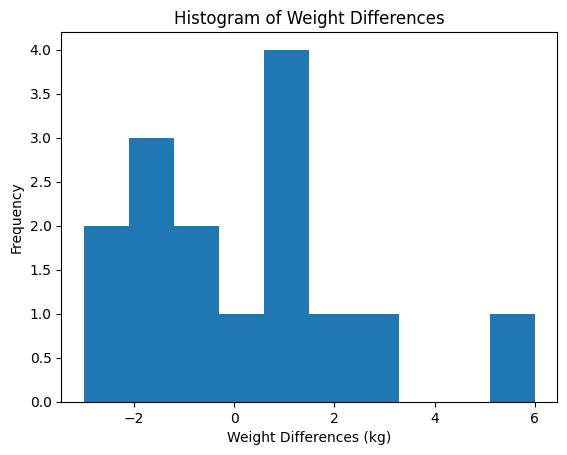

Shapiro-Wilk test: ShapiroResult(statistic=0.9220571486009436, pvalue=0.20704778986900568)


In [65]:
plt.hist(differences)
plt.title("Histogram of Weight Differences")
plt.xlabel("Weight Differences (kg)")
plt.ylabel("Frequency")
plt.show()

shapiro_test = stats.shapiro(differences)
print("Shapiro-Wilk test:", shapiro_test)


In [66]:
mean_diff = np.mean(differences)
std_diff = np.std(differences, ddof=1)

In [67]:
n = len(differences)
t_statistic = mean_diff / (std_diff / np.sqrt(n))
df = n - 1

In [68]:
t_statistic

0.10482848367219182

In [69]:
alpha = 0.05
p_value = stats.t.cdf(t_statistic, df)

In [70]:
p_value

0.5410005146857456

In [71]:
alpha=0.05

if p_value<alpha:
    print("reject thr null hypothesis")
else:
    print("fail to reject the null hypothesis")

fail to reject the null hypothesis
